В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tommykamaz/faces-dataset-small")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'faces-dataset-small' dataset.
Path to dataset files: /kaggle/input/faces-dataset-small


Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [3]:
def get_dataloader(image_size, batch_size):
    """
    Builds dataloader for training data.
    Use tt.Compose and tt.Resize for transformations
    :param image_size: height and wdith of the image
    :param batch_size: batch_size of the dataloader
    :returns: DataLoader object
    """
    # TODO: resize images, convert them to tensors and build dataloader

    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    dataset = ImageFolder(root=path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

    return dataloader

In [4]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [5]:
image_size = 128
batch_size = 64
ff_dl = get_dataloader(image_size, batch_size)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
ff_dl = DeviceDataLoader(ff_dl, device)
#TODO: build dataloader and transfer it to device

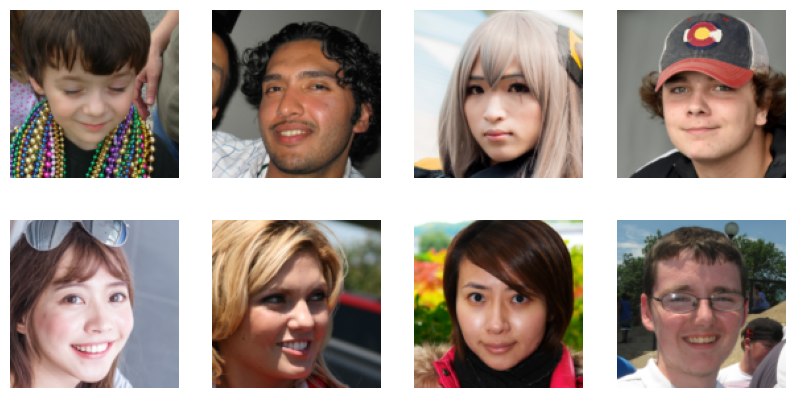

In [6]:
images, _ = next(iter(ff_dl))
images = images.cpu()
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)
    img = (img + 1) / 2
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.show()

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [7]:
discriminator = nn.Sequential(
    # in: 3 x 128 x 128
    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # 64 x 64 x 64

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # 128 x 32 x 32

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # 256 x 16 x 16

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # 512 x 8 x 8

    nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # 512 x 4 x 4

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
    # 1 x 1 x 1

    nn.Flatten(),
    nn.Sigmoid()
)

In [8]:
latent_size = 128

generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # 512 x 4 x 4

    nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # 512 x 8 x 8

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # 256 x 16 x 16

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # 128 x 32 x 32

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # 64 x 64 x 64

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # 3 x 128 x 128
)

In [9]:
# критик для WGAN
critic = nn.Sequential(
    # in: 3 x 128 x 128
    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    # 64 x 64 x 64

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    # 128 x 32 x 32

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    # 256 x 16 x 16

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    # 512 x 8 x 8

    nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    # 512 x 4 x 4

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
    # 1 x 1 x 1

    nn.Flatten()
)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0 - ОШИБКА?!
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [10]:
discriminator = to_device(discriminator, device)
generator = to_device(generator, device)

In [11]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [12]:
def fit(model, criterion, epochs, lr, start_idx=1):
    model["discriminator"].train()
    model["generator"].train()
    torch.cuda.empty_cache()

    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    # Create optimizers
    optimizer = {
        "discriminator": torch.optim.Adam(model["discriminator"].parameters(),
                                          lr=lr, betas=(0.5, 0.999)),
        "generator": torch.optim.Adam(model["generator"].parameters(),
                                      lr=lr, betas=(0.5, 0.999))
    }

    for epoch in range(epochs):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []
        for real_images, _ in tqdm(ff_dl, leave=False):
            # Train discriminator
            # Clear discriminator gradients
            optimizer["discriminator"].zero_grad()

            # Pass real images through discriminator
            real_preds = model["discriminator"](real_images)
            real_targets = torch.ones(real_images.size(0), 1, device=device)
            real_loss = criterion["discriminator"](real_preds, real_targets)
            cur_real_score = torch.mean(real_preds).item()

            # Generate fake images
            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            # Pass fake images through discriminator
            fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
            fake_preds = model["discriminator"](fake_images)
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)
            cur_fake_score = torch.mean(fake_preds).item()

            real_score_per_epoch.append(cur_real_score)
            fake_score_per_epoch.append(cur_fake_score)

            # Update discriminator weights
            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer["discriminator"].step()
            loss_d_per_epoch.append(loss_d.item())


            # Train generator
            # Clear generator gradients
            optimizer["generator"].zero_grad()

            # Generate fake images
            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            # Try to fool the discriminator
            preds = model["discriminator"](fake_images)
            targets = torch.ones(batch_size, 1, device=device)
            loss_g = criterion["generator"](preds, targets)

            # Update generator weights
            loss_g.backward()
            optimizer["generator"].step()
            loss_g_per_epoch.append(loss_g.item())

        # Record losses & scores
        losses_g.append(np.mean(loss_g_per_epoch))
        losses_d.append(np.mean(loss_d_per_epoch))
        real_scores.append(np.mean(real_score_per_epoch))
        fake_scores.append(np.mean(fake_score_per_epoch))

        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs,
            losses_g[-1], losses_d[-1], real_scores[-1], fake_scores[-1]))

        # Save generated images
        #if epoch == epochs - 1:
          #save_samples(epoch+start_idx, fixed_latent, show=False)

    return losses_g, losses_d, real_scores, fake_scores

In [13]:
epochs = 60
losses_g, losses_d, real_scores, fake_scores = fit(model, criterion, epochs, lr)

  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [1/60], loss_g: 9.0615, loss_d: 0.2257, real_score: 0.9267, fake_score: 0.0947


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [2/60], loss_g: 11.9834, loss_d: 0.4189, real_score: 0.9495, fake_score: 0.1065


  0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch [58/60], loss_g: 5.4913, loss_d: 0.4278, real_score: 0.8518, fake_score: 0.1419


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [59/60], loss_g: 5.1607, loss_d: 0.3241, real_score: 0.8817, fake_score: 0.1216


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [60/60], loss_g: 5.3461, loss_d: 0.3377, real_score: 0.8743, fake_score: 0.1153


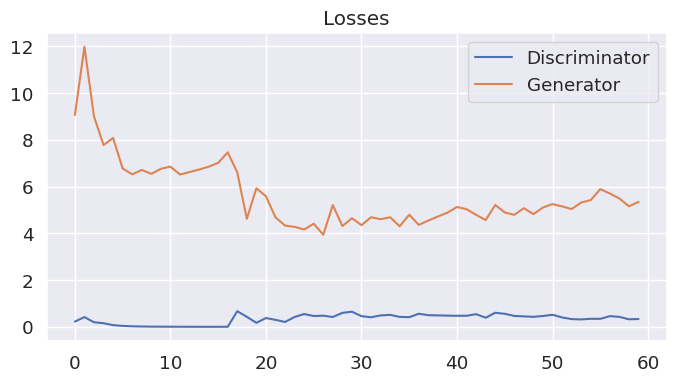

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(losses_d, '-')
plt.plot(losses_g, '-')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

стабилизируются

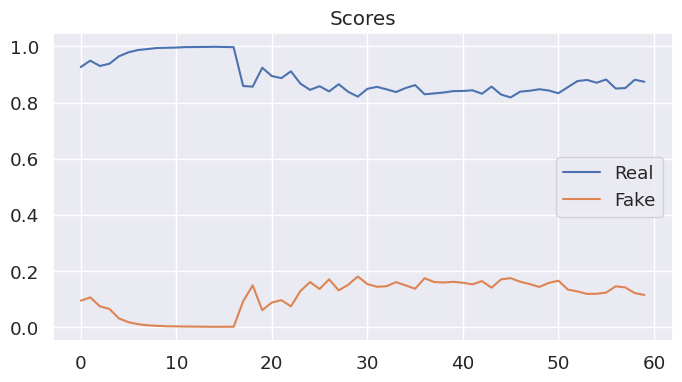

In [15]:
plt.figure(figsize=(8, 4))

plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.legend(['Real', 'Fake'])
plt.title('Scores');

скоры на тру -> 1 на фейке -> 0 это ок

In [16]:
# https://arxiv.org/pdf/1704.00028
def create_fit_wgan(epochs, lr=0.0001, lambda_gp=10, n_critic=5):
    L_list = []
    gen_loss_list = []

    critic_ = to_device(critic,device)
    generator_wgan = to_device(generator,device)

    optimizer_critic = torch.optim.Adam(critic_.parameters(), lr=lr, betas=(0.0, 0.9))
    optimizer_gen_wgan = torch.optim.Adam(generator_wgan.parameters(), lr=lr, betas=(0.0, 0.9))

    for epoch in tqdm(range(epochs)):
        L_list_per_epoch = []
        gen_loss_list_per_epoch = []

        for real_img, _ in tqdm(ff_dl, leave=False):
            b = real_img.size(0)  # batch size m

            # цикл критика
            for _ in range(n_critic):
                z = torch.randn(b, latent_size, 1, 1, device=device)
                fake_img = generator_wgan(z)

                D_real = critic_(real_img)
                D_fake = critic_(fake_img)

                # штраф
                eps = torch.rand(b, 1, 1, 1, device=device)  # из равномерного на 0,1
                x_hat = eps * real_img + (1 - eps) * fake_img
                x_hat.requires_grad_(True)

                D_hat = critic_(x_hat)

                grad = torch.autograd.grad(
                    outputs=D_hat,
                    inputs=x_hat,
                    grad_outputs=torch.ones_like(D_hat),
                    create_graph=True,
                    retain_graph=True
                )[0]

                grad_norm = grad.view(b, -1).norm(2, dim=1)
                gp = ((grad_norm - 1) ** 2).mean()

                L = D_fake.mean() - D_real.mean() + lambda_gp * gp

                optimizer_critic.zero_grad()
                L.backward()
                optimizer_critic.step()

                L_list_per_epoch.append(L.item())

            # гена
            z = torch.randn(b, latent_size, 1, 1, device=device)
            fake_img = generator_wgan(z)
            D_fake = critic_(fake_img)
            loss_g = -D_fake.mean()

            optimizer_gen_wgan.zero_grad()
            loss_g.backward()
            optimizer_gen_wgan.step()

            gen_loss_list_per_epoch.append(loss_g.item())

        L_list.append(np.mean(L_list_per_epoch))
        gen_loss_list.append(np.mean(gen_loss_list_per_epoch))
        print(f"Epoch [{epoch+1}/{epochs}], L: {np.mean(L_list_per_epoch):.4f}, loss_g: {np.mean(gen_loss_list_per_epoch):.4f}")

    model_wgan = {'critic' : critic_, 'generator': generator_wgan}

    return model_wgan, L_list, gen_loss_list

In [23]:
#create_fit_wgan(epochs, lr=0.0001, lambda_gp=10, n_critic=5):
epochs = 60
model_wgan, L_list, gen_wgan_losses = create_fit_wgan(epochs, lr=0.0001, lambda_gp=10, n_critic=5)

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [1/60], L: -5.5662, loss_g: 13.7281


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [2/60], L: -8.7414, loss_g: 8.4547


...

Epoch [58/60], L: -19.1241, loss_g: 4.4834


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [59/60], L: -19.9898, loss_g: 4.3688


  0%|          | 0/49 [00:00<?, ?it/s]

Epoch [60/60], L: -19.8217, loss_g: 1.9125


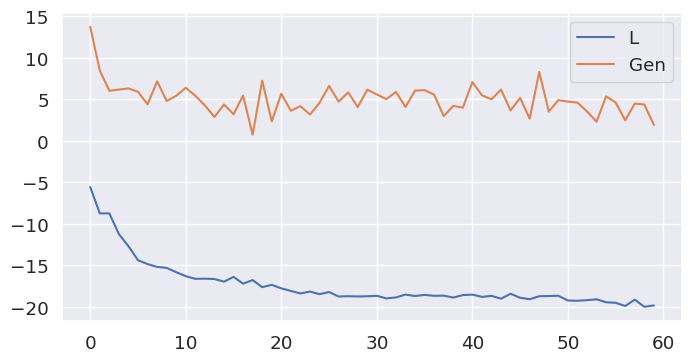

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(L_list, '-')
plt.plot(gen_wgan_losses, '-')
plt.legend(['L', 'Gen'])

стабилизируются

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [25]:
use_wgan = True
model_name = model_wgan if use_wgan else model
last_model_feature = -2 if use_wgan else -3
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model_name["generator"](fixed_latent)

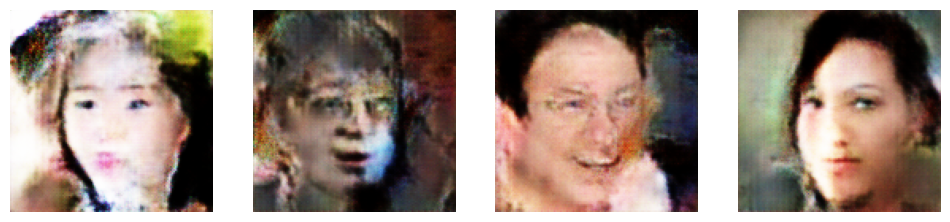

In [26]:
def show_images(generated):
    generated = generated.cpu().detach()
    fig, axes = plt.subplots(1, generated.size(0), figsize=(12, 4))
    for i, ax in enumerate(axes):
        img = generated[i].permute(1, 2, 0)
        img = (img + 1) / 2
        img = img.clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
    plt.show()

show_images(fake_images)

Как вам качество получившихся изображений?
GAN 2 эпохи чисто для теста - шум
WGAN - 20 эпох лица начали проступать WGAN 60 эпох в ячейке выше

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [21]:
def knn_loo(real_features, fake_features):
    X = np.vstack([real_features, fake_features])
    y = np.hstack([np.ones(len(real_features)), np.zeros(len(fake_features))])

    loo = LeaveOneOut()
    knn = KNeighborsClassifier(n_neighbors=1)

    scores = []
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn.fit(X_train, y_train)
        score = knn.score(X_test, y_test)
        scores.append(score)

    return np.mean(scores)

In [27]:
model_name

{'critic': Sequential(
   (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
   (1): LeakyReLU(negative_slope=0.2, inplace=True)
   (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
   (3): LeakyReLU(negative_slope=0.2, inplace=True)
   (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
   (5): LeakyReLU(negative_slope=0.2, inplace=True)
   (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
   (7): LeakyReLU(negative_slope=0.2, inplace=True)
   (8): Conv2d(512, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
   (9): LeakyReLU(negative_slope=0.2, inplace=True)
   (10): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
   (11): Flatten(start_dim=1, end_dim=-1)
 ),
 'generator': Sequential(
   (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
   (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=

In [28]:
if use_wgan:
    feature_extractor = nn.Sequential(*list(model_name['critic'].children())[:-2])
else:
    feature_extractor = nn.Sequential(*list(model_name["discriminator"].children())[:-3])

real_features = []
for real_images, _ in ff_dl:
    features = feature_extractor(real_images).cpu().detach().numpy()
    real_features.append(features.reshape(features.shape[0], -1))
real_features = np.vstack(real_features)


fake_features = []
for _ in range(len(ff_dl)):
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = model_name['generator'](latent)
    features = feature_extractor(fake_images).cpu().detach().numpy()
    fake_features.append(features.reshape(features.shape[0], -1))
fake_features = np.vstack(fake_features)[:len(real_features)]

print(real_features.shape)
print(fake_features.shape)


pca = PCA(n_components=200)
real_features_pca = pca.fit_transform(real_features)
fake_features_pca = pca.transform(fake_features)

accuracy = knn_loo(real_features_pca, fake_features_pca)
#accuracy = knn_loo(real_features, fake_features)
print(f"accuracy: {accuracy:.4f}")

(3136, 8192)
(3136, 8192)
accuracy: 0.6612


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

 идеальный генератор создаёт фейки, неотличимые от реальных сотв классификатор не может их различить и вынужден угадывать случайно, соотв accuracy стремится  к 0.5






*   GAN 2 эпохи 0.997 хорошо различили плохо сгенерировали
*   GAN 20 эпох  accuracy: 0.8533 уже лучше
*   WGAN 20 эпох  accuracy: 0.7962 уже лучше

*   GAN 60 эпох 0.8737
*   WGNA 60 эпох 0.6612 неплохо






### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

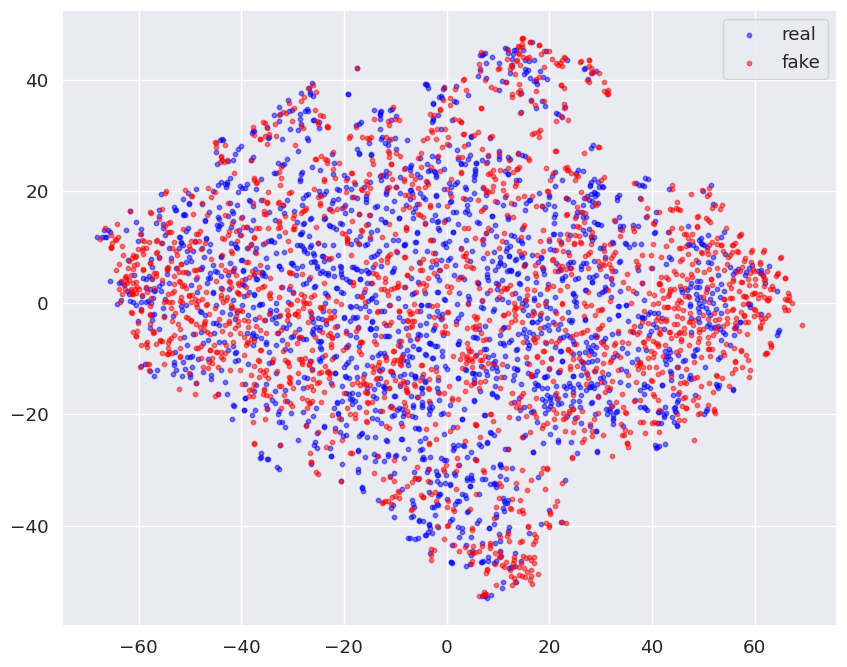

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

sample_size = 2000
real_sample = real_features[:sample_size]
fake_sample = fake_features[:sample_size]

X = np.vstack([real_sample, fake_sample])
y = np.hstack([np.ones(sample_size), np.zeros(sample_size)])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], c='blue', label='real', alpha=0.5, s=10)
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], c='red', label='fake', alpha=0.5, s=10)
plt.legend()
plt.show()

Прокомментируйте получившийся результат:

In [ ]:
на рис WGAN60
хорошее разделение - плохо для gan
те генератор не обманул дискриминатор

ну и наоборот: плохое разделение - хорошо